# Exploring Training Sizes

The goal of this experiment is to undestrand how the training size affects the performance of the model. We will train the model in the following number of samples by model: (2k, 3k, 5k, 10k, 15k and 20k). We will use the same collections for all models but with random choice.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
import os
import json
import joblib
import random
from pathlib import Path


from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from numpy import float64
from sklearn.metrics import roc_auc_score
from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed
from interpret.glassbox import ExplainableBoostingClassifier
from utils.model_loaders import load_logistic_models_for_subfolder

import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)



set_random_seed(42)
EXPERIMENTS = ["experiment_1"]

INFO 03-21 16:11:07 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform


In [2]:


def _get_split_sets(df, subfolder: str, split: str, num_collections: int, starting_collection_idx: int = 0, end_collection_idx: int = 19000):
    

    
    collections = random.sample(range(starting_collection_idx, end_collection_idx), num_collections)
    split_df = df.filter((pl.col("subfolder") == subfolder) & (pl.col("split") == split)).filter(pl.col("collection_idx").is_in(collections))
    X_split = []
    y_split = []

    for exp in EXPERIMENTS:
        exp_df = split_df.filter(pl.col("experiment") == exp)

        X_exp = exp_df.select("input").to_numpy()
        X_exp = np.array([i[0] for i in X_exp])
        y_exp = exp_df.select("evaluation").to_numpy()

        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        num_arrays = 500

        X_exp_reshaped = []
        y_exp_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_exp_reshaped.append(X_exp[i::num_arrays])
            y_exp_reshaped.append(y_exp[i::num_arrays])

        X_split.append(X_exp_reshaped)
        y_split.append(y_exp_reshaped)

    return X_split, y_split


def get_train_sets(df, subfolder, num_collections):
    return _get_split_sets(df, subfolder=subfolder, split="train", num_collections=num_collections)


# def get_test_sets(df, subfolder):
#     return _get_split_sets(df, subfolder=subfolder, split="test", num_collections=1000)

def get_holdout_groundruth_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="train", num_collections=1000, starting_collection_idx=19000, end_collection_idx=20000)

def get_holdout_judge_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="train", num_collections=1000, starting_collection_idx=19000, end_collection_idx=20000)

In [3]:
df = []

for subfolder in ["voting_alt1", "groundtruth"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"../binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 100]",i32,str,str,str
0,0,"[0, 1, … 0]",1,"""voting_alt1""","""experiment_1""","""train"""
0,1,"[0, 1, … 0]",0,"""voting_alt1""","""experiment_1""","""train"""
0,2,"[0, 1, … 0]",0,"""voting_alt1""","""experiment_1""","""train"""
0,3,"[0, 1, … 0]",0,"""voting_alt1""","""experiment_1""","""train"""
0,4,"[0, 1, … 0]",1,"""voting_alt1""","""experiment_1""","""train"""


In [ ]:
## Load best param


best_params = {
    "judge": [],
    "groundtruth": []
}

for f in sorted(os.listdir("../best_params")):
    _params = []
    results = json.load(open(f"../best_params/{f}", "r"))["results"]
    for p in results:
        try:
            _params.append(p["best_params"])
        except KeyError:
            _params.append(None)
    
    if "judge" in f:
        best_params["judge"].append(_params)
    else:
        best_params["groundtruth"].append(_params)

## Training and Collecting LR AUCs

### 500 Collections Training

In [ ]:
X_train_judge_500, y_train_judge_500 = get_train_sets(df, subfolder="voting_alt1", num_collections=500)
X_train_groundtruth_500, y_train_groundtruth_500 = get_train_sets(df, subfolder="groundtruth", num_collections=500)

judge_models_500 = []
groundtruth_models_500 = []

with tqdm(total=1 * 500, desc="Training models (500)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_500[i][j]
            y = y_train_judge_500[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            # Groundtruth model
            X = X_train_groundtruth_500[i][j]
            y = y_train_groundtruth_500[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0 or y.sum() == len(y):
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=100, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_500.append(_j_arr)
        groundtruth_models_500.append(_g_arr)

del X_train_judge_500, y_train_judge_500, X_train_groundtruth_500, y_train_groundtruth_500
gc.collect()

Training models (500):   3%|██▉                                                                                          | 16/500 [00:00<00:12, 39.54it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models (500):  14%|█████████████▏                                                                               | 71/500 [00:01<00:10, 42.13it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models (500):  20%|██████████████████▌                                                                         | 101/500 [00:02<00:12, 32.49it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

717

In [ ]:
### saving weights as tensores (500)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_500/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_500/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_500[exp]]), f"../weights/judge_500/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_500[exp]]), f"../weights/judge_500/{EXPERIMENTS[exp]}/bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_500[exp]]), f"../weights/groundtruth_500/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_500[exp]]), f"../weights/groundtruth_500/{EXPERIMENTS[exp]}/bias.pt")


### saving for datamodels generations (500)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_500/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_500/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_500[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_500[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_500[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_500[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/3002747946.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_500[exp]]), f"../weights/judge_500/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/3002747946.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_500[exp]]), f"../weights/groundtruth_500/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/3002747946.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and 

In [ ]:
## EVALUATE 500 MODELS
LOAD = False
if LOAD:
    judge_models_500 = load_logistic_models_for_subfolder("judge_500", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_500 = load_logistic_models_for_subfolder("groundtruth_500", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")
_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_500[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_500[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_500 = pl.DataFrame(_eval_df)
print(eval_df_500.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ judge       ┆ 0.556559 │
│ groundtruth ┆ 0.775952 │
└─────────────┴──────────┘


### 1K Collections Training

In [ ]:
X_train_judge_1k, y_train_judge_1k = get_train_sets(df, subfolder="voting_alt1", num_collections=1000)
X_train_groundtruth_1k, y_train_groundtruth_1k = get_train_sets(df, subfolder="groundtruth", num_collections=1000)

judge_models_1k = []
groundtruth_models_1k = []

with tqdm(total=1 * 500, desc="Training models (1k)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge mode
            X = X_train_judge_1k[i][j]
            y = y_train_judge_1k[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            # Groundtruth model
            X = X_train_groundtruth_1k[i][j]
            y = y_train_groundtruth_1k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=100, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_1k.append(_j_arr)
        groundtruth_models_1k.append(_g_arr)

del X_train_judge_1k, y_train_judge_1k, X_train_groundtruth_1k, y_train_groundtruth_1k
gc.collect()

Training models (1k):   4%|███▌                                                                                          | 19/500 [00:00<00:18, 26.47it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models (1k):  14%|█████████████▎                                                                                | 71/500 [00:02<00:20, 21.18it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models (1k):  21%|███████████████████▉                                                                         | 107/500 [00:04<00:14, 26.41it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

0

In [ ]:
### saving weights as tensores (1k)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_1k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_1k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_1k[exp]]), f"../weights/judge_1k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_1k[exp]]), f"../weights/judge_1k/{EXPERIMENTS[exp]}/bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_1k[exp]]), f"../weights/groundtruth_1k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_1k[exp]]), f"../weights/groundtruth_1k/{EXPERIMENTS[exp]}/bias.pt")


### saving for datamodels generations (1k)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_1k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_1k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_1k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_1k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_1k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_1k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/4229934917.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_1k[exp]]), f"../weights/judge_1k/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/4229934917.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_1k[exp]]), f"../weights/groundtruth_1k/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/4229934917.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will

In [ ]:
## EVALUATE 1K MODELS
LOAD = False
if LOAD:
    judge_models_1k = load_logistic_models_for_subfolder("judge_1k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_1k = load_logistic_models_for_subfolder("groundtruth_1k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")
_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_1k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_1k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_1k = pl.DataFrame(_eval_df)
print(eval_df_1k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ judge       ┆ 0.582933 │
│ groundtruth ┆ 0.810325 │
└─────────────┴──────────┘


### 2K Collections Training

In [ ]:
X_train_judge_2k, y_train_judge_2k = get_train_sets(df, subfolder="voting_alt1", num_collections=2000)
X_train_groundtruth_2k, y_train_groundtruth_2k = get_train_sets(df, subfolder="groundtruth", num_collections=2000)

judge_models_2k = []
groundtruth_models_2k = []

with tqdm(total=1 * 500, desc="Training models (2k)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_2k[i][j]
            y = y_train_judge_2k[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            # Groundtruth model
            X = X_train_groundtruth_2k[i][j]
            y = y_train_groundtruth_2k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=100, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_2k.append(_j_arr)
        groundtruth_models_2k.append(_g_arr)

del X_train_judge_2k, y_train_judge_2k, X_train_groundtruth_2k, y_train_groundtruth_2k
gc.collect()

Training models (2k):   4%|███▊                                                                                          | 20/500 [00:01<00:26, 17.78it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models (2k):  14%|█████████████▌                                                                                | 72/500 [00:04<00:35, 12.16it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models (2k):  22%|████████████████████▊                                                                        | 112/500 [00:07<00:19, 19.79it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

0

In [ ]:
### saving weights as tensores (2k)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_2k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_2k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_2k[exp]]), f"../weights/judge_2k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_2k[exp]]), f"../weights/judge_2k/{EXPERIMENTS[exp]}/bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_2k[exp]]), f"../weights/groundtruth_2k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_2k[exp]]), f"../weights/groundtruth_2k/{EXPERIMENTS[exp]}/bias.pt")


### saving for datamodels generations (2k)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_2k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_2k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_2k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_2k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_2k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_2k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/3802347545.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_2k[exp]]), f"../weights/judge_2k/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/3802347545.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_2k[exp]]), f"../weights/groundtruth_2k/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/3802347545.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will

In [ ]:
## EVALUATE 2K MODELS
LOAD = False
if LOAD:
    judge_models_2k = load_logistic_models_for_subfolder("judge_2k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_2k = load_logistic_models_for_subfolder("groundtruth_2k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")
_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_2k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_2k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_2k = pl.DataFrame(_eval_df)
print(eval_df_2k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ groundtruth ┆ 0.828817 │
│ judge       ┆ 0.600269 │
└─────────────┴──────────┘


### 3K Collections Training

In [ ]:
X_train_judge_3k, y_train_judge_3k = get_train_sets(df, subfolder="voting_alt1", num_collections=3000)
X_train_groundtruth_3k, y_train_groundtruth_3k = get_train_sets(df, subfolder="groundtruth", num_collections=3000)

judge_models_3k = []
groundtruth_models_3k = []




with tqdm(total=1 * 500, desc="Training models") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_3k[i][j]
            y = y_train_judge_3k[i][j].ravel()


            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            # Groundtruth model
            X = X_train_groundtruth_3k[i][j]
            y = y_train_groundtruth_3k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=100, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_3k.append(_j_arr)
        groundtruth_models_3k.append(_g_arr)

del X_train_judge_3k, y_train_judge_3k, X_train_groundtruth_3k, y_train_groundtruth_3k
gc.collect()

Training models:   4%|███▉                                                                                               | 20/500 [00:01<00:39, 12.19it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:  22%|█████████████████████▌                                                                            | 110/500 [00:10<00:34, 11.36it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
Training models:  36%|███████████████████████████████████▎                                                              | 180/500 [00:17<00:34,  9.28it/s]/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

327

In [ ]:
### saving weights as tensores


for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_3k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_3k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_3k[exp]]), f"../weights/judge_3k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_3k[exp]]), f"../weights/judge_3k/{EXPERIMENTS[exp]}/bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_3k[exp]]), f"../weights/groundtruth_3k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_3k[exp]]), f"../weights/groundtruth_3k/{EXPERIMENTS[exp]}/bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_3k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_3k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_3k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_3k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_3k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_3k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/1854527600.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_3k[exp]]), f"../weights/judge_3k/{EXPERIMENTS[exp]}/weights.pt")
/tmp/ipykernel_724783/1854527600.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_3k[exp]]), f"../weights/judge_3k/{EXPERIMENTS[exp]}/bias.pt")
/tmp/ipykernel_724783/1854527600.py:10: DeprecationWarning: Conversion of an a

In [ ]:
# ## EVALUATE 5K MODELS
LOAD = False
if LOAD:
    judge_models_3k = load_logistic_models_for_subfolder("judge_5k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_3k = load_logistic_models_for_subfolder("groundtruth_5k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")
_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_3k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_3k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_3k = pl.DataFrame(_eval_df)
print(eval_df_3k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ judge       ┆ 0.606818 │
│ groundtruth ┆ 0.834928 │
└─────────────┴──────────┘


### 5K Collections Training

In [ ]:
X_train_judge_5k, y_train_judge_5k = get_train_sets(df, subfolder="voting_alt1", num_collections=5000)
X_train_groundtruth_5k, y_train_groundtruth_5k = get_train_sets(df, subfolder="groundtruth", num_collections=5000)

judge_models_5k = []
groundtruth_models_5k = []

with tqdm(total=1 * 500, desc="Training models (5k)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_5k[i][j]
            y = y_train_judge_5k[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            ## Groundtruth model
            X = X_train_groundtruth_5k[i][j]
            y = y_train_groundtruth_5k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_5k.append(_j_arr)
        groundtruth_models_5k.append(_g_arr)


del X_train_judge_5k, y_train_judge_5k, X_train_groundtruth_5k, y_train_groundtruth_5k
gc.collect()

Training models (5k): 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:23<00:00,  6.01it/s]


0

In [ ]:
### saving weights as tensores (5k)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_5k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_5k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_5k[exp]]), f"../weights/judge_5k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_5k[exp]]), f"../weights/judge_5k/{EXPERIMENTS[exp]}/lr_5k_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_5k[exp]]), f"../weights/groundtruth_5k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_5k[exp]]), f"../weights/groundtruth_5k/{EXPERIMENTS[exp]}/lr_5k_bias.pt")


### saving for datamodels generations (5k)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_5k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_5k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_5k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_5k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_5k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_5k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/2314102278.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_5k[exp]]), f"../weights/judge_5k/{EXPERIMENTS[exp]}/lr_5k_bias.pt")
/tmp/ipykernel_724783/2314102278.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_5k[exp]]), f"../weights/groundtruth_5k/{EXPERIMENTS[exp]}/lr_5k_bias.pt")
/tmp/ipykernel_724783/2314102278.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecat

In [ ]:
## EVALUATE 5K MODELS
LOAD = False
if LOAD:
    judge_models_5k = load_logistic_models_for_subfolder("judge_5k", "weights.pt", "bias.pt", experiments=EXPERIMENT, weights_dir="../weights")
    groundtruth_models_5k = load_logistic_models_for_subfolder("groundtruth_5k", "weights.pt", "bias.pt", experiments=EXPERIMENT, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")

_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_5k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_5k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_5k = pl.DataFrame(_eval_df)
print(eval_df_5k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ groundtruth ┆ 0.842059 │
│ judge       ┆ 0.613629 │
└─────────────┴──────────┘


### 10K Collections Training

In [ ]:
X_train_judge_10k, y_train_judge_10k = get_train_sets(df, subfolder="voting_alt1", num_collections=10000)
X_train_groundtruth_10k, y_train_groundtruth_10k = get_train_sets(df, subfolder="groundtruth", num_collections=10000)

judge_models_10k = []
groundtruth_models_10k = []

with tqdm(total=1 * 500, desc="Training models (10k)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_10k[i][j]
            y = y_train_judge_10k[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            ## Groundtruth model
            X = X_train_groundtruth_10k[i][j]
            y = y_train_groundtruth_10k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_10k.append(_j_arr)
        groundtruth_models_10k.append(_g_arr)


del X_train_judge_10k, y_train_judge_10k, X_train_groundtruth_10k, y_train_groundtruth_10k
gc.collect()

Training models (10k): 100%|████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [02:32<00:00,  3.28it/s]


0

In [ ]:
### saving weights as tensores (10k)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_10k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_10k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_10k[exp]]), f"../weights/judge_10k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_10k[exp]]), f"../weights/judge_10k/{EXPERIMENTS[exp]}/lr_10k_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_10k[exp]]), f"../weights/groundtruth_10k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_10k[exp]]), f"../weights/groundtruth_10k/{EXPERIMENTS[exp]}/lr_10k_bias.pt")


### saving for datamodels generations (10k)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_10k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_10k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_10k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_10k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_10k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_10k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/962174562.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_10k[exp]]), f"../weights/judge_10k/{EXPERIMENTS[exp]}/lr_10k_bias.pt")
/tmp/ipykernel_724783/962174562.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_10k[exp]]), f"../weights/groundtruth_10k/{EXPERIMENTS[exp]}/lr_10k_bias.pt")
/tmp/ipykernel_724783/962174562.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is depre

In [ ]:
## EVALUATE 10K MODELS
LOAD = False
if LOAD:
    judge_models_10k = load_logistic_models_for_subfolder("judge_10k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_10k = load_logistic_models_for_subfolder("groundtruth_10k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")

_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_10k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_10k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_10k = pl.DataFrame(_eval_df)
print(eval_df_10k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ judge       ┆ 0.621891 │
│ groundtruth ┆ 0.849865 │
└─────────────┴──────────┘


### 15K Collections Training

In [ ]:
X_train_judge_15k, y_train_judge_15k = get_train_sets(df, subfolder="voting_alt1", num_collections=15000)
X_train_groundtruth_15k, y_train_groundtruth_15k = get_train_sets(df, subfolder="groundtruth", num_collections=15000)

judge_models_15k = []
groundtruth_models_15k = []

with tqdm(total=1 * 500, desc="Training models (15k)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_15k[i][j]
            y = y_train_judge_15k[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            ## Groundtruth model
            X = X_train_groundtruth_15k[i][j]
            y = y_train_groundtruth_15k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_15k.append(_j_arr)
        groundtruth_models_15k.append(_g_arr)


del X_train_judge_15k, y_train_judge_15k, X_train_groundtruth_15k, y_train_groundtruth_15k
gc.collect()

Training models (15k): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [03:50<00:00,  2.17it/s]


0

In [ ]:
### saving weights as tensores (15k)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_15k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_15k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_15k[exp]]), f"../weights/judge_15k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_15k[exp]]), f"../weights/judge_15k/{EXPERIMENTS[exp]}/lr_15k_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_15k[exp]]), f"../weights/groundtruth_15k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_15k[exp]]), f"../weights/groundtruth_15k/{EXPERIMENTS[exp]}/lr_15k_bias.pt")


### saving for datamodels generations (15k)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_15k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_15k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_15k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_15k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_15k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_15k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/3527327568.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_15k[exp]]), f"../weights/judge_15k/{EXPERIMENTS[exp]}/lr_15k_bias.pt")
/tmp/ipykernel_724783/3527327568.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_15k[exp]]), f"../weights/groundtruth_15k/{EXPERIMENTS[exp]}/lr_15k_bias.pt")
/tmp/ipykernel_724783/3527327568.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is de

In [ ]:
## EVALUATE 15K MODELS
LOAD = False
if LOAD:
    judge_models_15k = load_logistic_models_for_subfolder("judge_15k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_15k = load_logistic_models_for_subfolder("groundtruth_15k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")

_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_15k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_15k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_15k = pl.DataFrame(_eval_df)
print(eval_df_15k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ groundtruth ┆ 0.853024 │
│ judge       ┆ 0.625648 │
└─────────────┴──────────┘


### 19K Collections Training

In [ ]:
X_train_judge_19k, y_train_judge_19k = get_train_sets(df, subfolder="voting_alt1", num_collections=19000)
X_train_groundtruth_19k, y_train_groundtruth_19k = get_train_sets(df, subfolder="groundtruth", num_collections=19000)

judge_models_19k = []
groundtruth_models_19k = []

with tqdm(total=1 * 500, desc="Training models (19k)") as pbar:
    for i in range(1):
        _j_arr, _g_arr = [], []
        
        for j in range(500):
            # Judge model
            X = X_train_judge_19k[i][j]
            y = y_train_judge_19k[i][j].ravel()

            if best_params["judge"][i][j] is None:
                _j_arr.append(None)
            else:
                model = LogisticRegression(**best_params["judge"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _j_arr.append(model)

            ## Groundtruth model
            X = X_train_groundtruth_19k[i][j]
            y = y_train_groundtruth_19k[i][j].ravel()

            if best_params["groundtruth"][i][j] is None or y.sum() == 0:
                _g_arr.append(None)
            else:
                model = LogisticRegression(**best_params["groundtruth"][i][j], max_iter=2000, random_state=42)
                model.fit(X, y)
                _g_arr.append(model)
            
            pbar.update(1)
        
        judge_models_19k.append(_j_arr)
        groundtruth_models_19k.append(_g_arr)


del X_train_judge_19k, y_train_judge_19k, X_train_groundtruth_19k, y_train_groundtruth_19k
gc.collect()

Training models (19k): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [05:03<00:00,  1.65it/s]


0

In [ ]:
### saving weights as tensores (20k)

for exp in range(len(EXPERIMENTS)):
    os.makedirs(f"../weights/judge_19k/{EXPERIMENTS[exp]}", exist_ok=True)
    os.makedirs(f"../weights/groundtruth_19k/{EXPERIMENTS[exp]}", exist_ok=True)
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_19k[exp]]), f"../weights/judge_19k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_19k[exp]]), f"../weights/judge_19k/{EXPERIMENTS[exp]}/lr_19k_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_19k[exp]]), f"../weights/groundtruth_19k/{EXPERIMENTS[exp]}/weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_19k[exp]]), f"../weights/groundtruth_19k/{EXPERIMENTS[exp]}/lr_19k_bias.pt")


### saving for datamodels generations (20k)
for exp in range(len(EXPERIMENTS)):
    jg_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/judge_19k/"
    gt_path = f"../runs/{EXPERIMENTS[exp]}/datamodels/models/groundtruth_19k/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models_19k[exp]]), f"{jg_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_19k[exp]]), f"{jg_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models_19k[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_19k[exp]]), f"{gt_path}/0_499_bias.pt")

/tmp/ipykernel_724783/2095441010.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in judge_models_19k[exp]]), f"../weights/judge_19k/{EXPERIMENTS[exp]}/lr_19k_bias.pt")
/tmp/ipykernel_724783/2095441010.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in groundtruth_models_19k[exp]]), f"../weights/groundtruth_19k/{EXPERIMENTS[exp]}/lr_19k_bias.pt")
/tmp/ipykernel_724783/2095441010.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is de

In [ ]:
## EVALUATE 20K MODELS
LOAD = False
if LOAD:
    judge_models_19k = load_logistic_models_for_subfolder("judge_19k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")
    groundtruth_models_19k = load_logistic_models_for_subfolder("groundtruth_19k", "weights.pt", "bias.pt", experiments=EXPERIMENTS, weights_dir="../weights")

X_test_judge, y_test_judge = get_holdout_judge_sets(df, subfolder="voting_alt1")
X_test_groundtruth, y_test_groundtruth = get_holdout_groundruth_sets(df, subfolder="groundtruth")

_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}

for i in range(1):
    for j in range(500):
        model = judge_models_19k[i][j]
        if model is not None:
            _x = X_test_judge[i][j]
            _y = y_test_judge[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        model = groundtruth_models_19k[i][j]
        if model is not None:
            _x = X_test_groundtruth[i][j]
            _y = y_test_groundtruth[i][j].ravel()
            score = roc_auc_score(_y, model.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)


eval_df_20k = pl.DataFrame(_eval_df)
print(eval_df_20k.filter(pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean()))

shape: (2, 2)
┌─────────────┬──────────┐
│ type        ┆ auc      │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ groundtruth ┆ 0.853804 │
│ judge       ┆ 0.627362 │
└─────────────┴──────────┘


### AUC Results Summary

shape: (16, 3)
┌───────────────┬─────────────┬──────────┐
│ training_size ┆ type        ┆ mean_auc │
│ ---           ┆ ---         ┆ ---      │
│ i32           ┆ str         ┆ f64      │
╞═══════════════╪═════════════╪══════════╡
│ 500           ┆ judge       ┆ 0.556559 │
│ 500           ┆ groundtruth ┆ 0.775952 │
│ 1000          ┆ judge       ┆ 0.582933 │
│ 1000          ┆ groundtruth ┆ 0.810325 │
│ 2000          ┆ judge       ┆ 0.600269 │
│ …             ┆ …           ┆ …        │
│ 10000         ┆ groundtruth ┆ 0.849865 │
│ 15000         ┆ groundtruth ┆ 0.853024 │
│ 15000         ┆ judge       ┆ 0.625648 │
│ 19000         ┆ groundtruth ┆ 0.853804 │
│ 19000         ┆ judge       ┆ 0.627362 │
└───────────────┴─────────────┴──────────┘


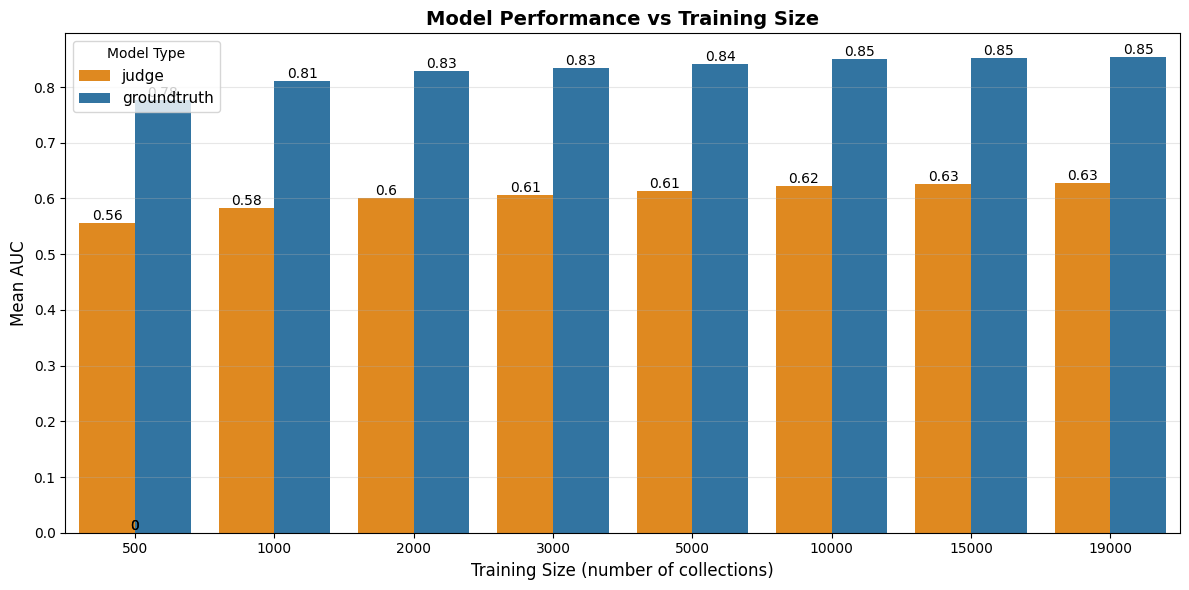

In [ ]:
# Combine all evaluation dataframes with training size labels
eval_results = []

# List of (eval_df, training_size) pairs
eval_pairs = [
    (eval_df_500, 500),
    (eval_df_1k, 1000),
    (eval_df_2k, 2000),
    (eval_df_3k, 3000),
    (eval_df_5k, 5000),
    (eval_df_10k, 10000),
    (eval_df_15k, 15000),
    (eval_df_20k, 19000),
]

for eval_df, size in eval_pairs:
    eval_df_with_size = eval_df.with_columns(
        pl.lit(size).alias("training_size")
    )
    eval_results.append(eval_df_with_size)

# Combine all results
combined_results = pl.concat(eval_results)

# Filter out null and nan values
combined_results_clean = combined_results.filter(
    pl.col("auc").is_not_null() & pl.col("auc").is_not_nan()
)

# Calculate mean AUC by training size and type
summary_stats = combined_results_clean.group_by("training_size", "type").agg(
    pl.col("auc").mean().alias("mean_auc")
).sort("training_size")

print(summary_stats)

# Create barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=summary_stats.to_pandas(),
    x="training_size",
    y="mean_auc",
    hue="type",
    palette={"judge": "#FF8C00", "groundtruth": "#1f77b4"},
    hue_order=["judge", "groundtruth"]
)

# Add value labels above each bar with 2 significant figures
for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height:.2g}',
            ha='center', va='bottom', fontsize=10)

plt.xlabel("Training Size (number of collections)", fontsize=12)
plt.ylabel("Mean AUC", fontsize=12)
plt.title("Model Performance vs Training Size", fontsize=14, fontweight="bold")
plt.legend(title="Model Type", fontsize=11)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Evaluate RAG Performance

In [4]:
models = [
    "groundtruth_500", "groundtruth_1k", "groundtruth_2k", "groundtruth_3k", "groundtruth_5k", "groundtruth_10k", "groundtruth_15k", "groundtruth_19k",
    "judge_500", "judge_1k", "judge_2k", "judge_3k", "judge_5k", "judge_10k", "judge_15k", "judge_19k"
]

wiki = pl.read_ipc(f"../../../data/wiki_dump2018_nq_open/processed/wiki.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"../runs/{exp}/questions.feather"
        for model in models:
            dfs_generations.append(calculate_agg_metric(
                metrics=["rouge_l", "squad_v2_best_exact"],
                generation_path=f"../runs/{exp}/generations/{model}.json",
                reference_path=questions_path,
                saving_path=None
            )
                .with_columns([
                    pl.lit(model.split("_")[0]).alias("model_type"),
                    pl.lit(model.split("_")[1]).alias("model_size")
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("results.feather")
else:
    generations_results = pl.read_ipc("results.feather")

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Calculating rouge_l...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--rouge/b01e0accf3bd6dd24839b769a5fda24e14995071570870922c71970b3a6ed886 (last modified on Wed Oct 16 22:50:24 2024) since it couldn't be found locally at evaluate-metric--rouge, or remotely on the Hugging Face Hub.


Calculating squad_v2_best_exact...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


...

Calculating rouge_l...


Calculating squad_v2_best_exact...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Calculating rouge_l...


Calculating squad_v2_best_exact...


In [7]:
generations_results

idx,value,metric,model_type,model_size
i64,list[f32],str,str,str
0,[1.0],"""rouge_l""","""groundtruth""","""500"""
1,[0.4],"""rouge_l""","""groundtruth""","""500"""
2,[1.0],"""rouge_l""","""groundtruth""","""500"""
3,[1.0],"""rouge_l""","""groundtruth""","""500"""
4,[1.0],"""rouge_l""","""groundtruth""","""500"""
…,…,…,…,…
495,[0.0],"""squad_v2_best_exact""","""judge""","""19k"""
496,[0.0],"""squad_v2_best_exact""","""judge""","""19k"""
497,[0.0],"""squad_v2_best_exact""","""judge""","""19k"""


## Performance Metrics by Model Type and Size

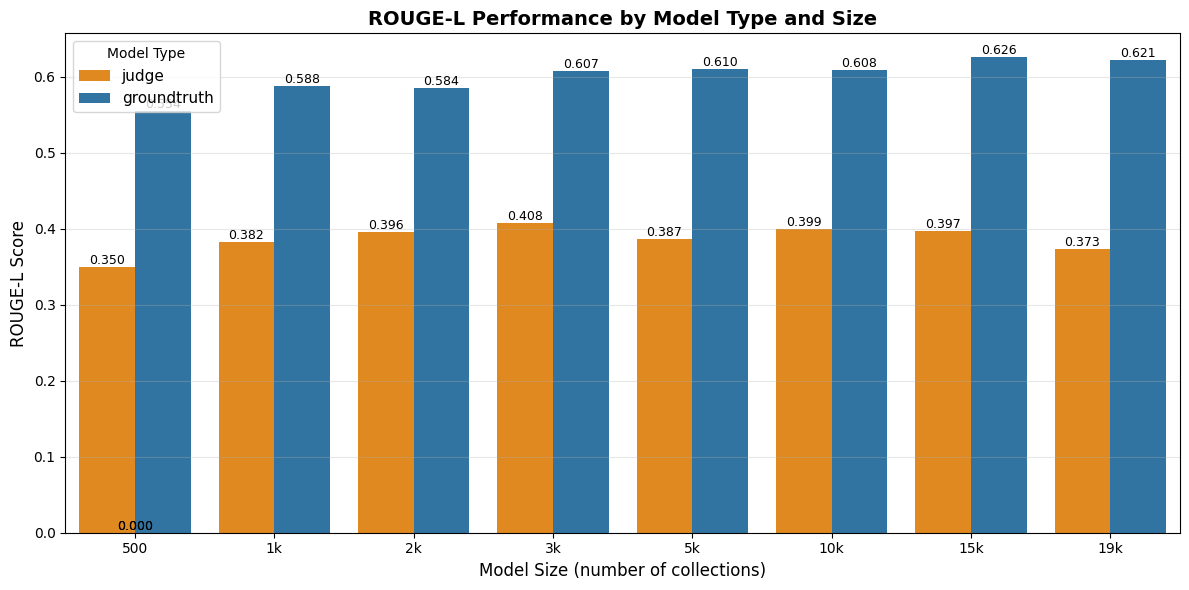

In [8]:
# Sort model_size for proper ordering
size_order = ["500", "1k", "2k", "3k", "5k", "10k", "15k", "19k"]

# Prepare data for ROUGE-L plot
# Unnest the value column and filter for rouge_l metric
rouge_results = (generations_results
    .filter(pl.col("metric") == "rouge_l")
    .with_columns(pl.col("value").list.first().alias("rouge_l_value"))
    .select(["model_type", "model_size", "rouge_l_value"])
    .group_by(["model_type", "model_size"])
    .agg(pl.col("rouge_l_value").mean().alias("rouge_l"))
    .to_pandas())

# Create figure for ROUGE-L
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=rouge_results,
    x="model_size",
    y="rouge_l",
    hue="model_type",
    palette={"judge": "#FF8C00", "groundtruth": "#1f77b4"},
    hue_order=["judge", "groundtruth"],
    order=size_order,
    ax=ax
)

# Add value labels above each bar with 3 decimal places
for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Model Size (number of collections)", fontsize=12)
ax.set_ylabel("ROUGE-L Score", fontsize=12)
ax.set_title("ROUGE-L Performance by Model Type and Size", fontsize=14, fontweight="bold")
ax.legend(title="Model Type", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

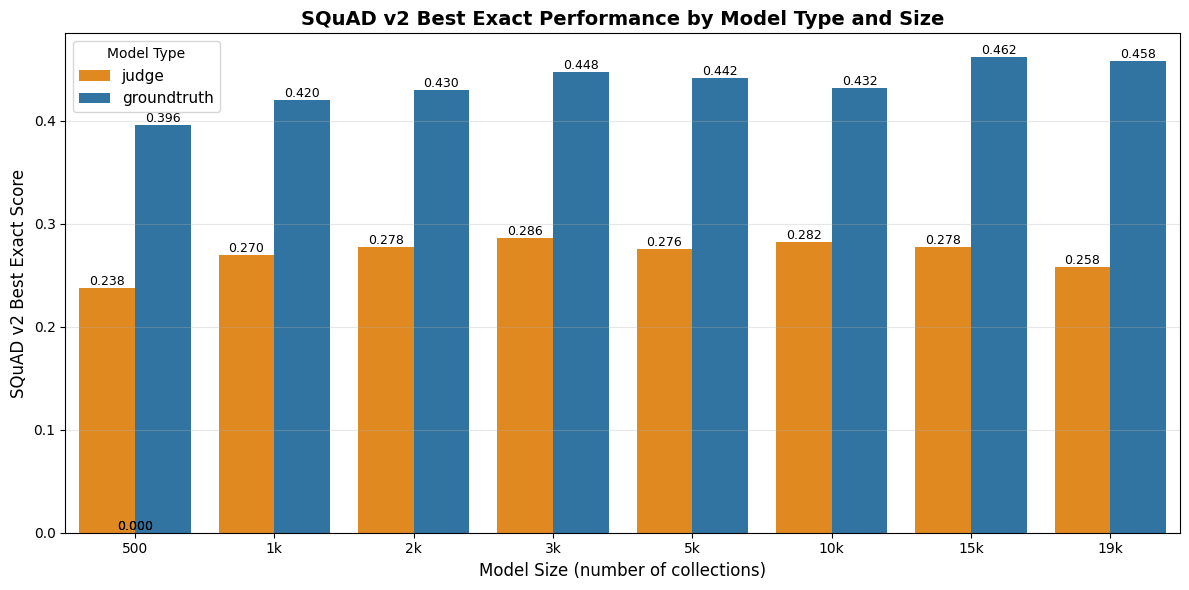

In [9]:
# Prepare data for SQuAD v2 Best Exact plot
# Unnest the value column and filter for squad_v2_best_exact metric
squad_results = (generations_results
    .filter(pl.col("metric") == "squad_v2_best_exact")
    .with_columns(pl.col("value").list.first().alias("squad_value"))
    .select(["model_type", "model_size", "squad_value"])
    .group_by(["model_type", "model_size"])
    .agg(pl.col("squad_value").mean().alias("squad_v2_best_exact"))
    .to_pandas())

# Create figure for SQuAD v2 Best Exact
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=squad_results,
    x="model_size",
    y="squad_v2_best_exact",
    hue="model_type",
    palette={"judge": "#FF8C00", "groundtruth": "#1f77b4"},
    hue_order=["judge", "groundtruth"],
    order=size_order,
    ax=ax
)

# Add value labels above each bar with 3 decimal places
for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel("Model Size (number of collections)", fontsize=12)
ax.set_ylabel("SQuAD v2 Best Exact Score", fontsize=12)
ax.set_title("SQuAD v2 Best Exact Performance by Model Type and Size", fontsize=14, fontweight="bold")
ax.legend(title="Model Type", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()